#  EDA: Samsung Global Product Sales Dataset


## About the dataset:
15,500 synthetic sales transactions for Galaxy S, Z Fold/Flip, Galaxy A/M, Tablets, Watches, Buds, Smart TVs, Monitors & Appliances
across 52 countries, 555+ cities, sorted by Country → City → Date (2021 – 2024).

This dataset simulates a realistic global sales ledger for Samsung Electronics products.It spans flagship foldables to budget smartphones, smart home devices, and accessories —making it ideal for market segmentation, price analysis, 5G adoption tracking, time-series forecasting, and cross-country revenue analysis.

## Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
from prophet import Prophet
import warnings

## Reading Data Frame

In [13]:
df = pd.read_csv('samsung_global_sales_dataset.csv')

## Exploring The Data

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  object 
 1   sale_date               15500 non-null  object 
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  object 
 4   month                   15500 non-null  object 
 5   country                 15500 non-null  object 
 6   region                  15500 non-null  object 
 7   city                    15500 non-null  object 
 8   product_name            15500 non-null  object 
 9   category                15500 non-null  object 
 10  storage                 7651 non-null   object 
 11  color                   15500 non-null  object 
 12  is_5g                   15500 non-null  object 
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null

In [15]:
df.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'storage', 'color', 'is_5g',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'customer_rating',
       'return_status'],
      dtype='object')

In [16]:
df.shape

(15500, 28)

In [17]:
df.dtypes

,0
sale_id,object
sale_date,object
year,int64
quarter,object
month,object
country,object
region,object
city,object
product_name,object
category,object


In [18]:
df.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,1.550000e+04,11249.000000
mean,2022.511935,665.116825,5.708452,2.360000,627.134001,1478.145734,1054.528710,1.595853e+06,3.743515
std,1.113496,736.014360,6.406814,1.897958,695.723305,2368.688098,4062.232887,1.092157e+07,0.721258
min,2021.000000,8.200000,0.000000,1.000000,6.600000,6.610000,0.790000,6.080000e+00,2.500000
25%,2022.000000,185.435000,0.000000,1.000000,172.780000,254.265000,1.360000,1.199072e+03,3.100000
50%,2023.000000,421.490000,3.000000,2.000000,397.410000,739.380000,10.650000,7.813940e+03,3.700000
75%,2024.000000,938.657500,10.000000,3.000000,882.907500,1695.315000,110.000000,9.126992e+04,4.400000
max,2024.000000,5442.700000,20.000000,10.000000,5442.700000,47665.900000,24500.000000,3.647727e+08,5.000000


## Cheking for Data Quality

In [19]:
df.isnull().sum()

,0
sale_id,0
sale_date,0
year,0
quarter,0
month,0
country,0
region,0
city,0
product_name,0
category,0


In [20]:
df.duplicated().sum()

np.int64(0)

### Checking for Outliars

In [21]:
df_numeric = df.select_dtypes(include=[np.number])

Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (df_numeric < lower_bound) | (df_numeric > upper_bound)

print(outliers.sum())

year                         0
unit_price_usd             434
discount_pct                 0
units_sold                 788
discounted_price_usd       436
revenue_usd               1387
fx_rate_to_usd            3045
revenue_local_currency    2858
customer_rating              0
dtype: int64


**Premium Flagships (unit_price_usd & discounted_price_usd):** The 434–436 outliers represent Samsung’s Appliances. These are "Price Outliers" because they sit far above the price of phones.

**Bulk/Enterprise Orders (units_sold):** The 788 outliers in units sold indicate B2B (Business-to-Business) sales or major retail restocking events. These are crucial because a single "Outlier" row might represent more revenue than 100 "Normal" rows.

**High-Value Transactions (revenue_usd):** With 1,387 outliers, your revenue is heavily "Top-Heavy." This confirms that a small percentage of sales (likely the premium devices sold in bulk) drives the majority of Samsung's financial success.

**Currency Volatility (fx_rate_to_usd & revenue_local_currency):** The high number of outliers (over 3,000) shows that Samsung operates in markets with vastly different currency scales (like the Korean Won or Vietnamese Dong) compared to the USD. This highlights the complexity of international sales.

## Exploring Numeric Features

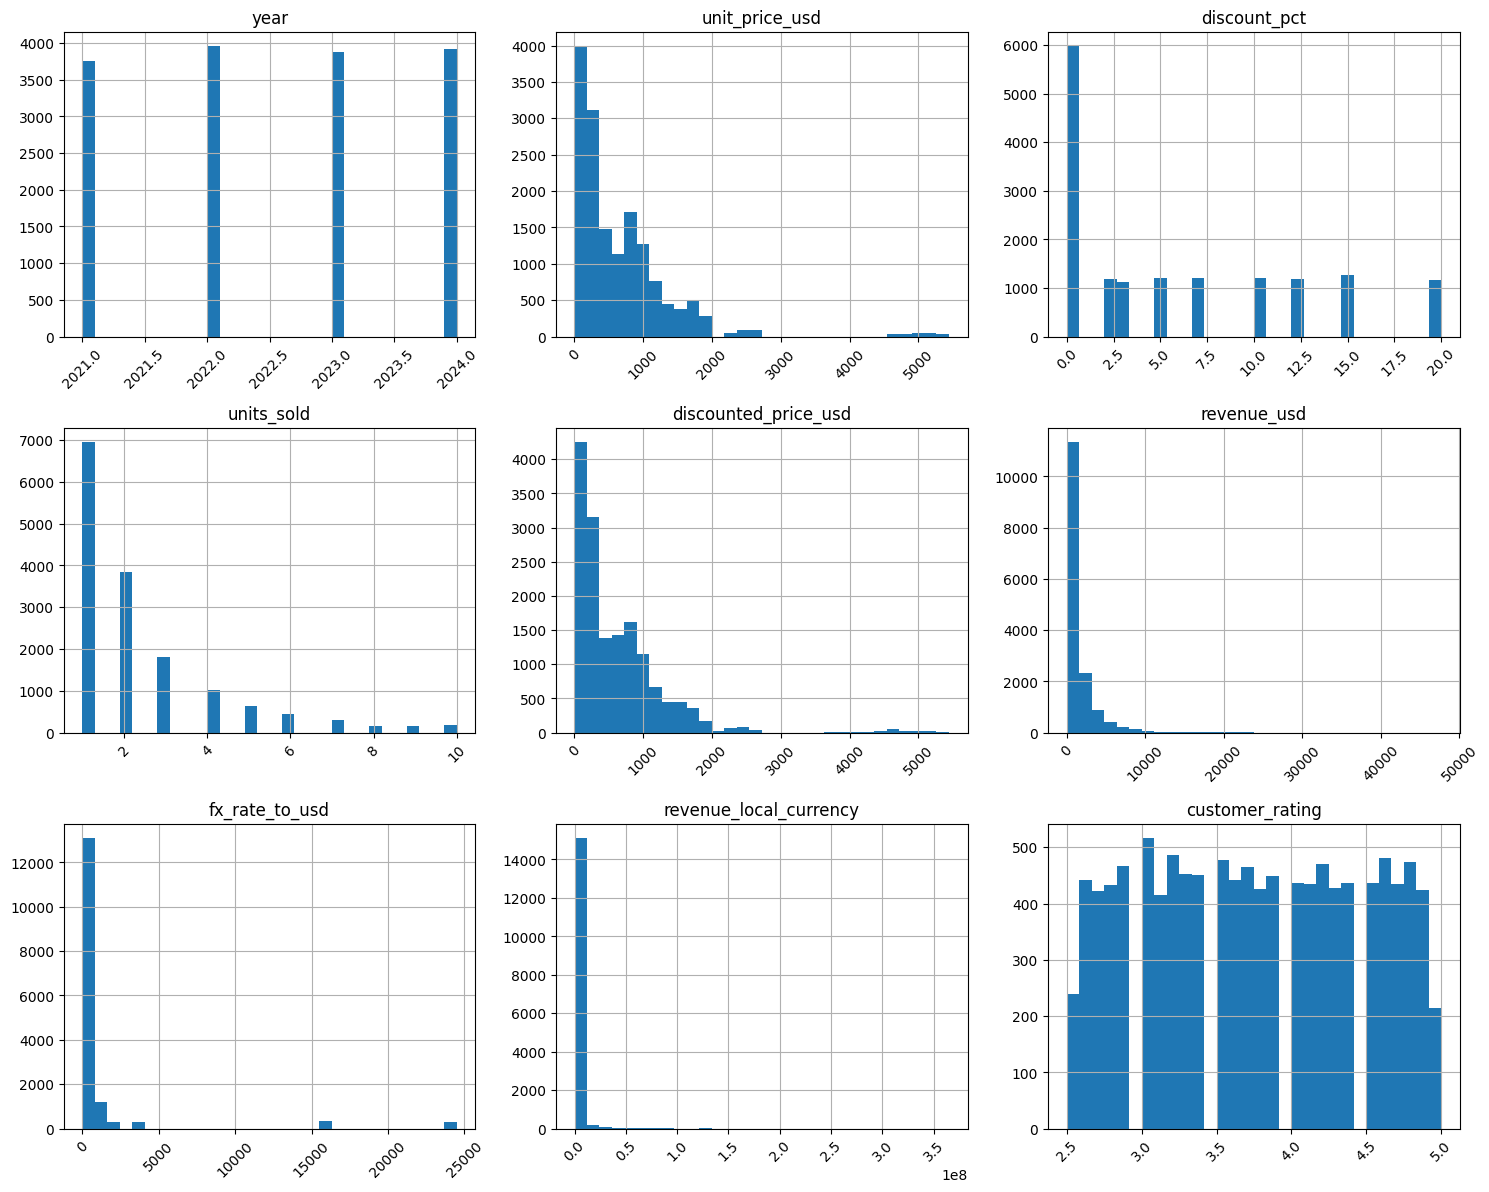

In [22]:
hists = df.hist(figsize=(15, 12), bins=30,)
for ax in hists.flatten():
  ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Right-Skewed Distributions (Price, Units & Revenue):** most bars are clustered on the left with a long tail stretching to the right. This confirms that Samsung sells a high volume of affordable/mid-range devices, while high-revenue flagship sales are rarer but present.

**Discounts:** We can see tall spikes at specific numbers especially 0%. This shows that discounts aren't random; they follow a strict corporate pricing strategy or seasonal "Sales Events."

**Uniform/Categorical Distribution (year):** This shows consistent data collection across the year.

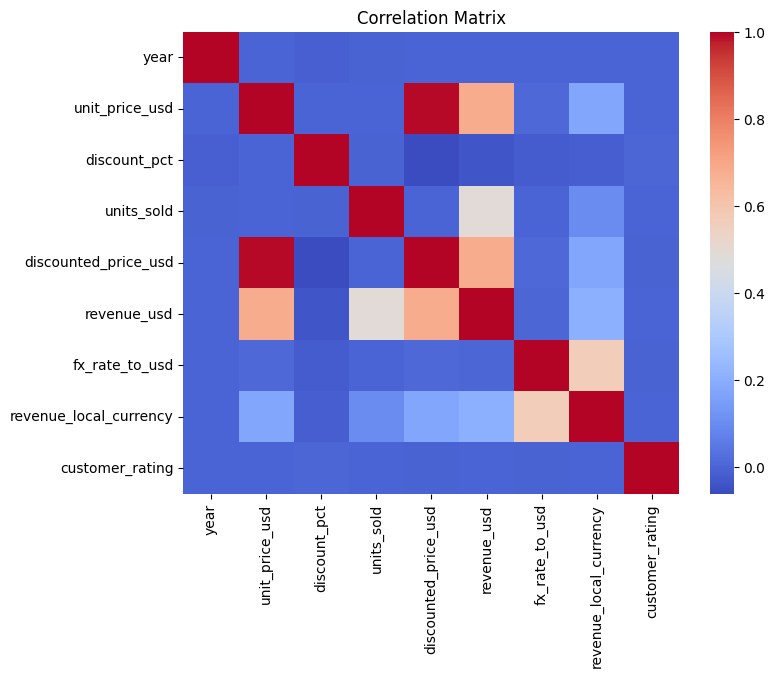

In [23]:
corr_matrix = df_numeric.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix')
plt.show()

**Price vs. Revenue ($0.68$):** High Price = High Revenue. Means Samsung makes its real money from expensive flagships, not cheap volume.

**Price Redundancy ($0.99$):** Unit Price $\approx$ Discounted Price. Means discounts are tiny and don't change the phone's "luxury" status.

**FX Factor ($0.56$):** Exchange Rate moves with Local Revenue. Means global currency shifts hit the wallet harder than actual sales performance.

**Rating Paradox ($0.00$):** Rating $\neq$ Sales. Means reviews don't matter; people buy for the brand and the new tech regardless of stars.

**Outlier Reality:** Big spikes in volume/revenue. Means B2B and Black Friday are rare but carry the entire business.

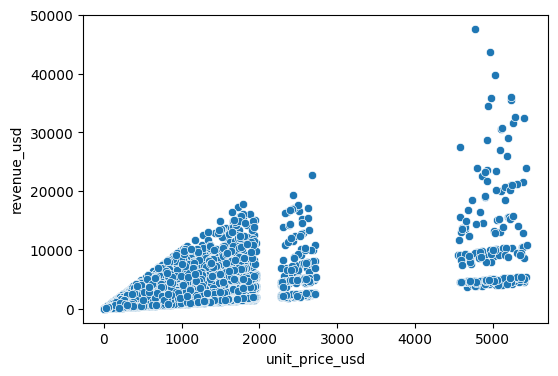

In [25]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='unit_price_usd', y='revenue_usd', data=df)
plt.title('')
plt.show()


In [ ]:
# this proves that price and revenue are correlated and by increasing price revenue increases

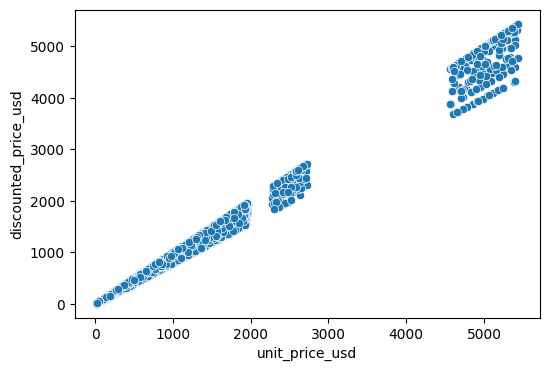

In [26]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='unit_price_usd', y='discounted_price_usd', data=df)
plt.title('')
plt.show()


In [ ]:
# here we see how discounted price can be derived from the unit price.

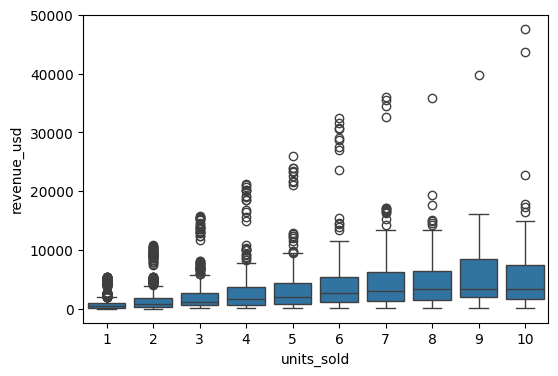

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x='units_sold', y='revenue_usd', data=df)
plt.title('')
plt.show()


## Exploring Categorical Features

In [28]:
df_cat = df.select_dtypes(exclude=[np.number]) # working only on cateorical features
df_cat.columns

Index(['sale_id', 'sale_date', 'quarter', 'month', 'country', 'region', 'city',
       'product_name', 'category', 'storage', 'color', 'is_5g', 'currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'return_status'],
      dtype='object')

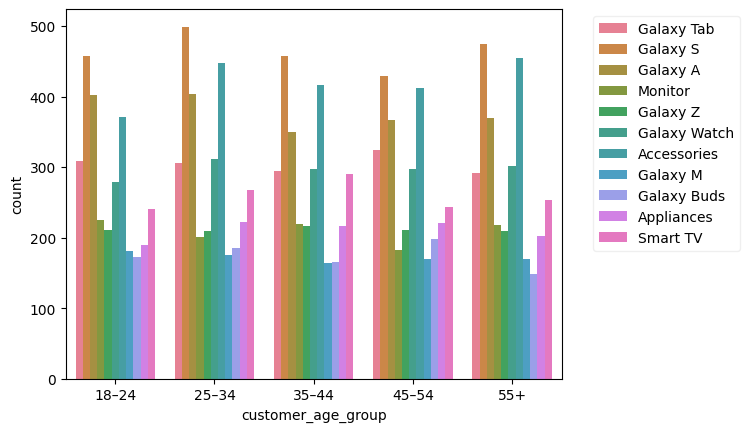

In [29]:
# reordering ages for better interpretation
sorted_ages = sorted(df['customer_age_group'].unique())

sns.countplot(hue='category', x='customer_age_group', data=df,order=sorted_ages)
plt.title('')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', framealpha=0.3)
plt.show()


In [ ]:
# this graph shows how slightly the category sales are affected by the age group.
# this is unusual which is due to the fact that the data is synthetic

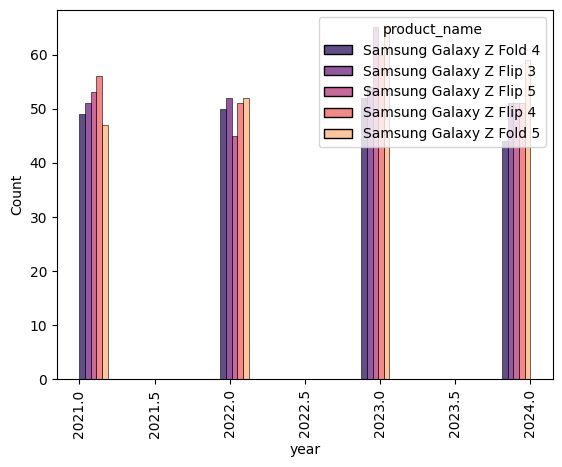

In [30]:
df_Zs = df[(df['category']=='Galaxy Z')]
sns.histplot( hue='product_name', x='year',kde=False,  multiple="dodge", palette='magma', data=df_Zs)
plt.title('')
plt.xticks(rotation=90)
plt.show()


In [52]:
# as we look at this plot we can see how the Z series was the most popular in
# 2023 as it was a popular trend amongst buyers then spiked down the following year

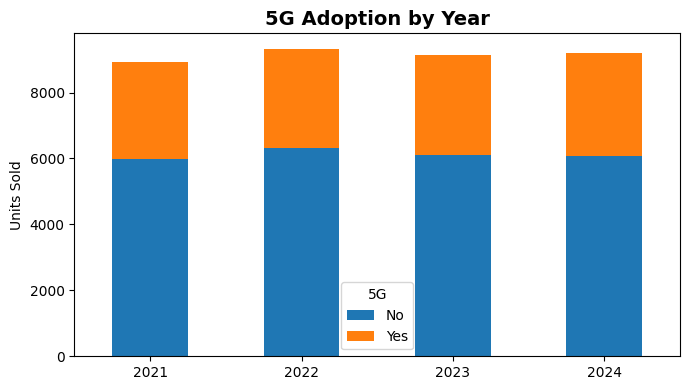

In [31]:
g5 = df.groupby(['year', 'is_5g'])['units_sold'].sum().unstack()

g5.plot(kind='bar', stacked=True, figsize=(7, 4))
plt.title('5G Adoption by Year', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Units Sold')
plt.xticks(rotation=0)
plt.legend(title='5G')
plt.tight_layout()
plt.show()

In [ ]:
# this plot shows how the adoption of 5g didnt grow along the years and stayed consistant
# which could call for better advertisement.

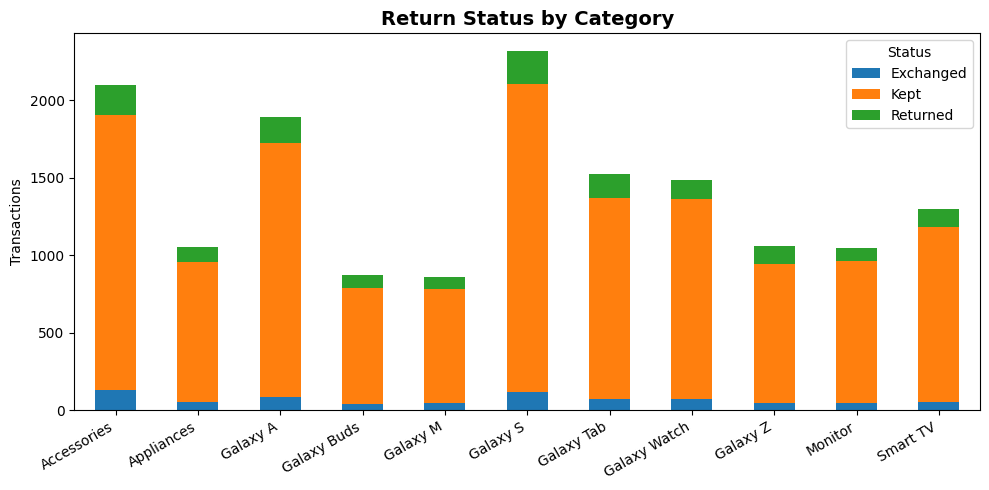

In [32]:
ret = df.groupby(['category', 'return_status'])['sale_id'].count().unstack()

ret.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Return Status by Category', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Transactions')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()



In [ ]:
# This plot shows that the most exchanged items were accessories which could mean getting wrong fits or colors.
# most kept is phones as its usually a well thought process and its the main selling item.

## Exploring Categorical and Numerical Features

In [33]:
map_data = df['country'].value_counts().reset_index()
map_data.columns = ['country', 'sales_count']

fig = px.choropleth(map_data, locations="country", locationmode='country names', color="sales_count", hover_name="country",
                    title="Global Sales Volume by Country", color_continuous_scale="Viridis")
fig.show()

In [53]:
# we can see how revenue is distributed across the map, countries like china have low revenue as samsung isnt
# popularly used there, due to the alternative companies, while countries in the east have high
# revenue as samsung is one of the most popular phone brands there, while in the rest of the countries revenue was in the
# middle as the competition is high in the phone market

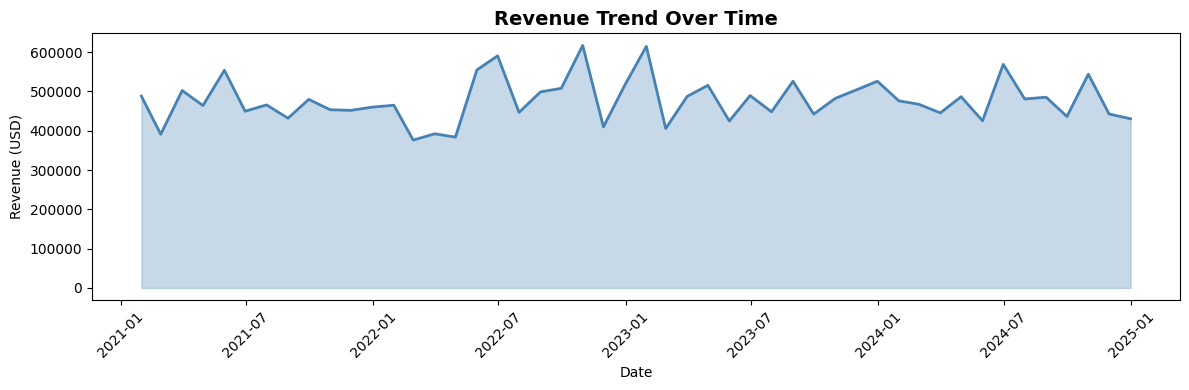

In [34]:
df['sale_date'] = pd.to_datetime(df['sale_date'])
trend = df.set_index('sale_date').resample('ME')['revenue_usd'].sum()

plt.figure(figsize=(12, 4))
plt.fill_between(trend.index, trend.values, alpha=0.3, color='steelblue')
plt.plot(trend.index, trend.values, color='steelblue', linewidth=2)
plt.title('Revenue Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# we see how revenue spikes over time and it shows years where revenue drop and spikes should be studied to learn from.

/tmp/ipykernel_348/2515245237.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




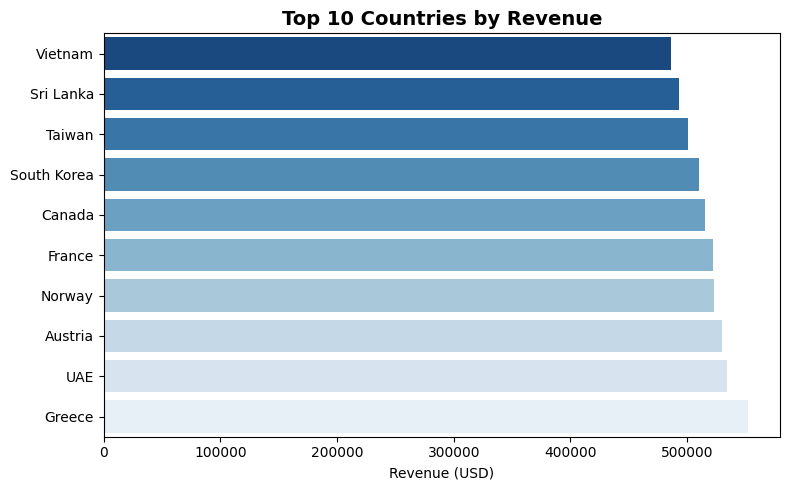

In [35]:
top_countries = df.groupby('country')['revenue_usd'].sum().nlargest(10).sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (USD)')
plt.ylabel('')
plt.tight_layout()
plt.show()



In [ ]:
# the highest revenue comes from greece which could mean learning from the marketing plan there
# to apply in other countries

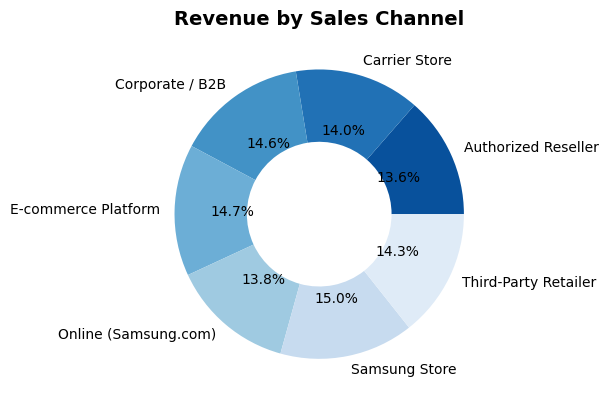

In [36]:
ch_rev = df.groupby('sales_channel')['revenue_usd'].sum()

plt.figure(figsize=(6, 6))
plt.pie(ch_rev.values, labels=ch_rev.index, autopct='%1.1f%%',
        colors=sns.color_palette('Blues_r', len(ch_rev)),
        wedgeprops=dict(width=0.5))
plt.title('Revenue by Sales Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# this plot tells us how samsung stores bring the most revenue and so more budget should be given
# to focus on it more to bring out more revenue, overall revenue is equally distributed along
# all channels

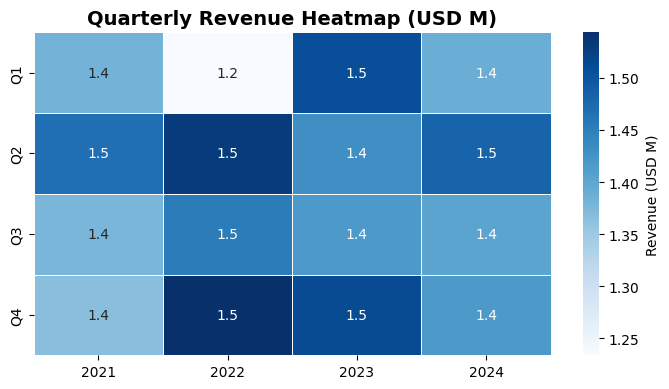

In [37]:
q_heat = df.groupby(['year', 'quarter'])['revenue_usd'].sum()
q_pivot = q_heat.unstack(level='year') / 1e6

plt.figure(figsize=(7, 4))
sns.heatmap(q_pivot, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Revenue (USD M)'})
plt.title('Quarterly Revenue Heatmap (USD M)', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# we can see how the year 2022 had the most revenue across all quarters while in other years
# highest quarter revenue wasnt consistantly in a specific quarter.

/tmp/ipykernel_348/361333606.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




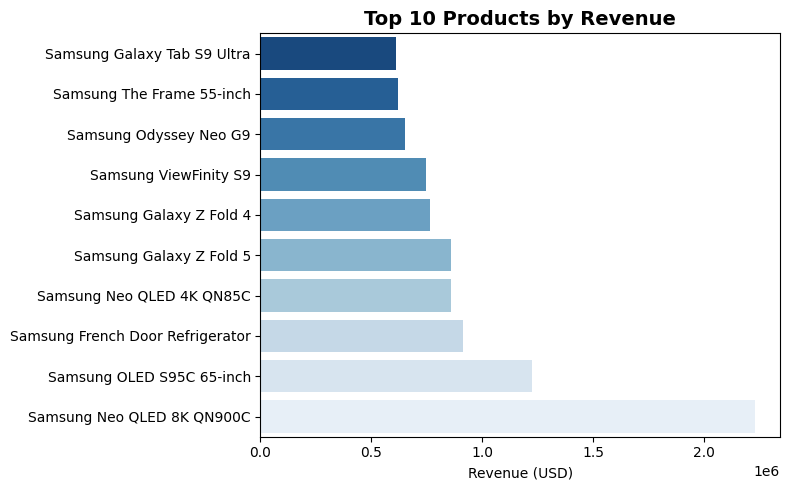

In [38]:
top_prod = df.groupby('product_name')['revenue_usd'].sum().nlargest(10).sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=top_prod.values, y=top_prod.index, palette='Blues_r')
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (USD)')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
# the tvs seem to have the most revenue then the Z phones then finally the S9 Tab ultra which shows how the
# revenue is dominated by tv sales, and so they should be the focus and marketing budget should target them more

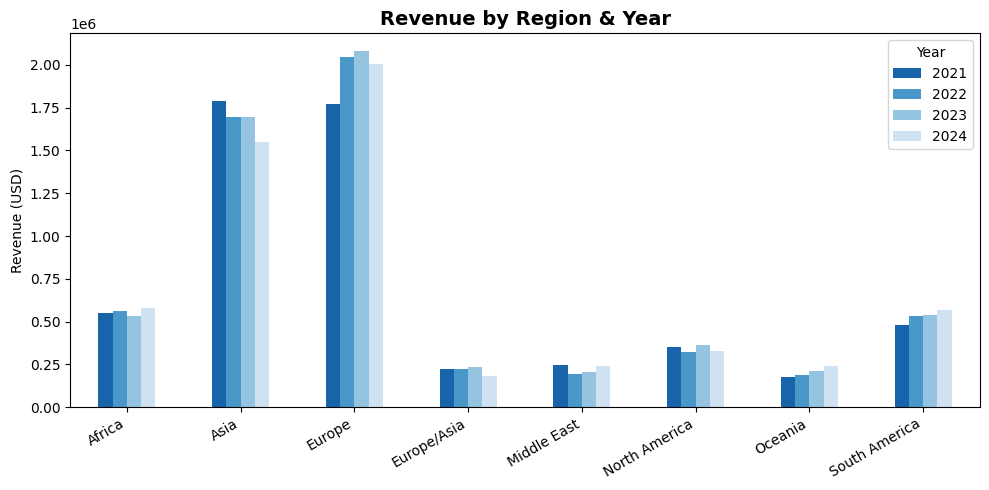

In [39]:
reg_yr = df.groupby(['region', 'year'])['revenue_usd'].sum().unstack()

reg_yr.plot(kind='bar', figsize=(10, 5),
            color=sns.color_palette('Blues_r', len(reg_yr.columns)))
plt.title('Revenue by Region & Year', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [ ]:
# we see a spike in asia and europe's  revenue across the years, indicating good market for samsung there,
# while in other regions better marketing should be applied to get more revenue,
# in asia the revenue is dropping down even tho its quite high compared to the rest, possibly for the competition
# samsung is facing in asia

## Data Cleaning

### Checking for Null Values

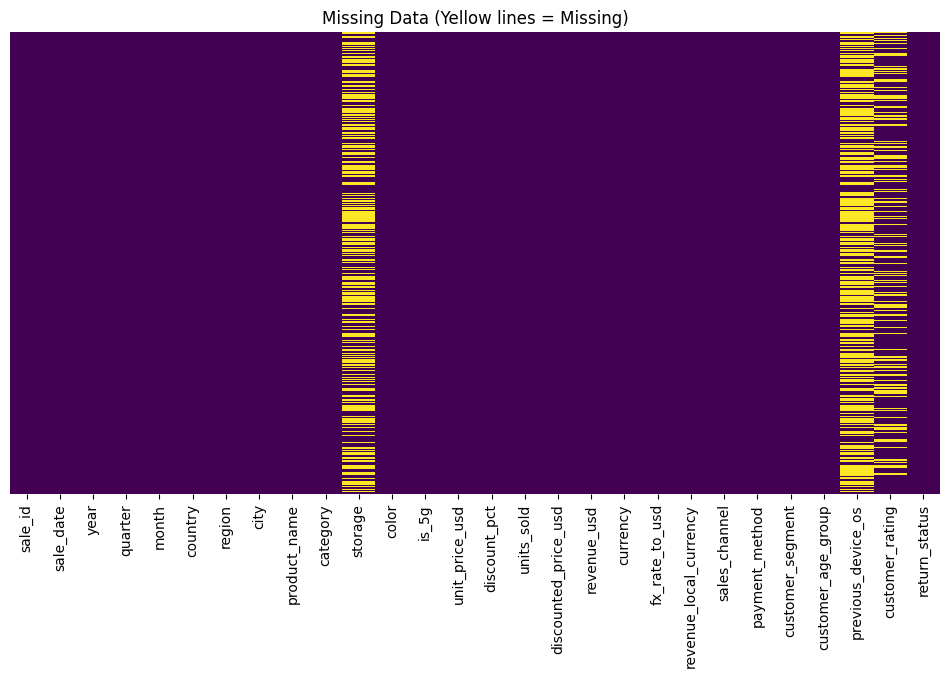

In [40]:

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data (Yellow lines = Missing)')
plt.show()

In [41]:
df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].median())

In [42]:
df['previous_device_os'] = df['previous_device_os'].fillna('UnKnown')

In [43]:
df['storage'] = df.groupby('product_name')['storage'].transform(lambda x : x.fillna(x.mode()[0] if not x.mode().empty else "128GB"))

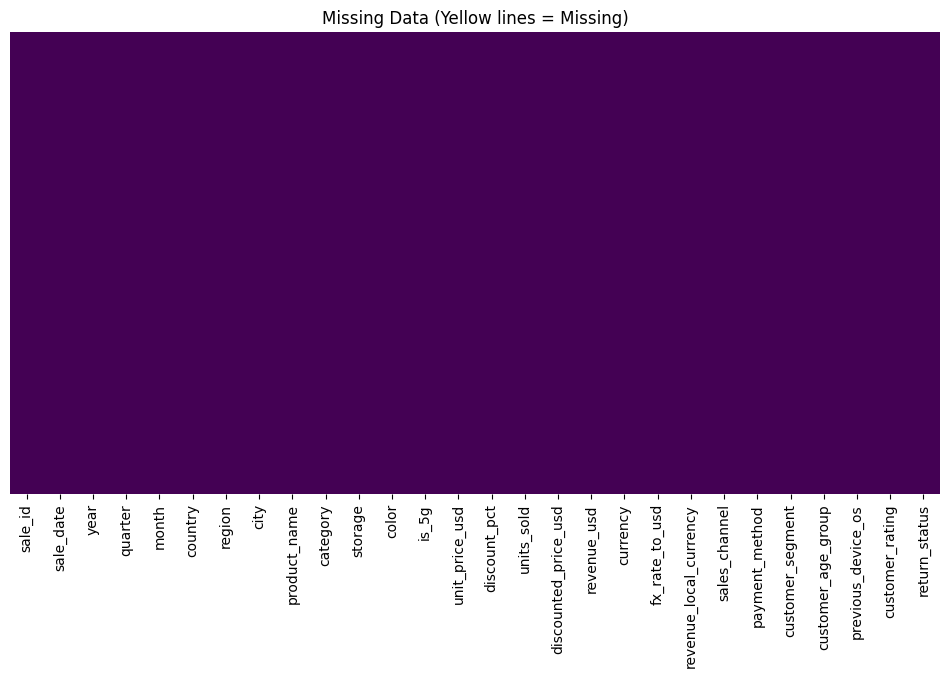

In [44]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data (Yellow lines = Missing)')
plt.show()

## Feature Engineering

In [45]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

In [46]:
monthly = df.set_index('sale_date').resample('ME')['revenue_usd'].sum().reset_index()
monthly.columns = ['ds', 'y']

In [47]:
monthly2 = df.set_index('sale_date').resample('ME')['units_sold'].sum().reset_index()
monthly2.columns = ['ds', 'y']

## Machine Learning Predictions

### Baseline model

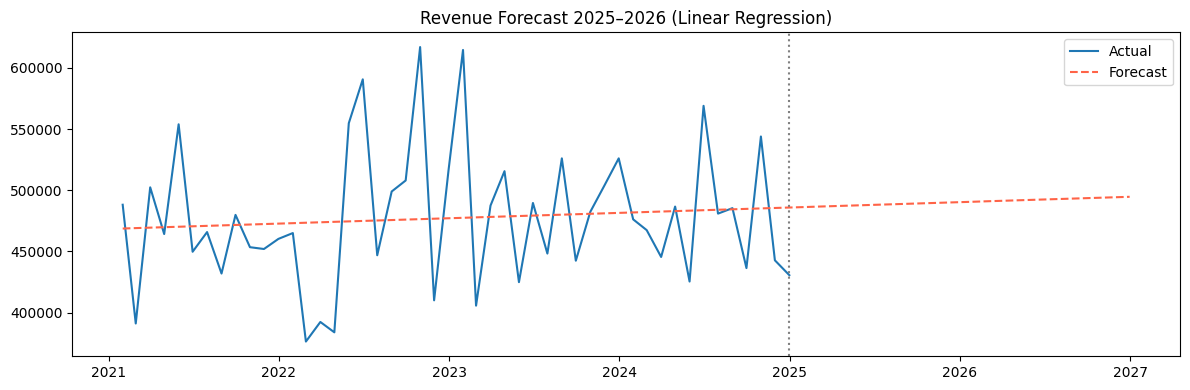

In [48]:
# Data selection
X = np.arange(len(monthly)).reshape(-1, 1)

# Fitting the model
model = LinearRegression().fit(X, monthly['y'])

# Creating future values to predict revenue
X_future = np.arange(len(monthly) + 24).reshape(-1, 1)

# Model predictions
y_pred   = model.predict(X_future)

# Preparing x-axis
future_dates = pd.date_range(monthly['ds'].iloc[-1], periods=25, freq='ME')[1:]
all_dates    = monthly['ds'].tolist() + future_dates.tolist()

# Plotting predictions
plt.figure(figsize=(12, 4))
plt.plot(monthly['ds'], monthly['y'], label='Actual')
plt.plot(all_dates, y_pred, linestyle='--', color='tomato', label='Forecast')
plt.axvline(x=monthly['ds'].iloc[-1], color='gray', linestyle=':')
plt.title('Revenue Forecast 2025–2026 (Linear Regression)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# the model doesnt perform well it underfits the data as it ignores seasonality and quarter trends.

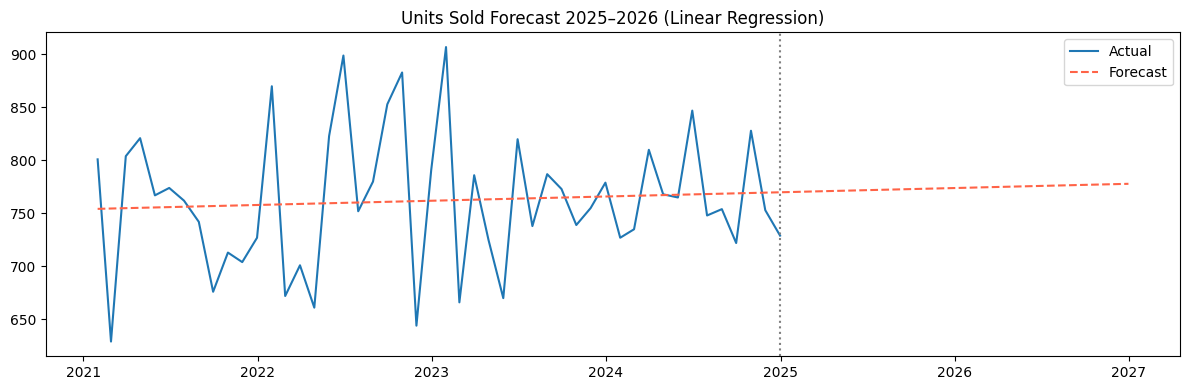

In [49]:
# Data selection
X = np.arange(len(monthly2)).reshape(-1, 1)

# Fitting the model
model2 = LinearRegression().fit(X, monthly2['y'])

# Creating future values to predict revenue
X_future2 = np.arange(len(monthly2) + 24).reshape(-1, 1)

# Model predictions
y_pred2   = model2.predict(X_future2)

# Preparing x-axis
future_dates = pd.date_range(monthly2['ds'].iloc[-1], periods=25, freq='ME')[1:]
all_dates    = monthly2['ds'].tolist() + future_dates.tolist()

# Plotting predictions
plt.figure(figsize=(12, 4))
plt.plot(monthly2['ds'], monthly2['y'], label='Actual')
plt.plot(all_dates, y_pred2, linestyle='--', color='tomato', label='Forecast')
plt.axvline(x=monthly2['ds'].iloc[-1], color='gray', linestyle=':')
plt.title('Units Sold Forecast 2025–2026 (Linear Regression)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# the model here underfits as well for the same reasons of missing seasonality and quarter trends

### Final Model

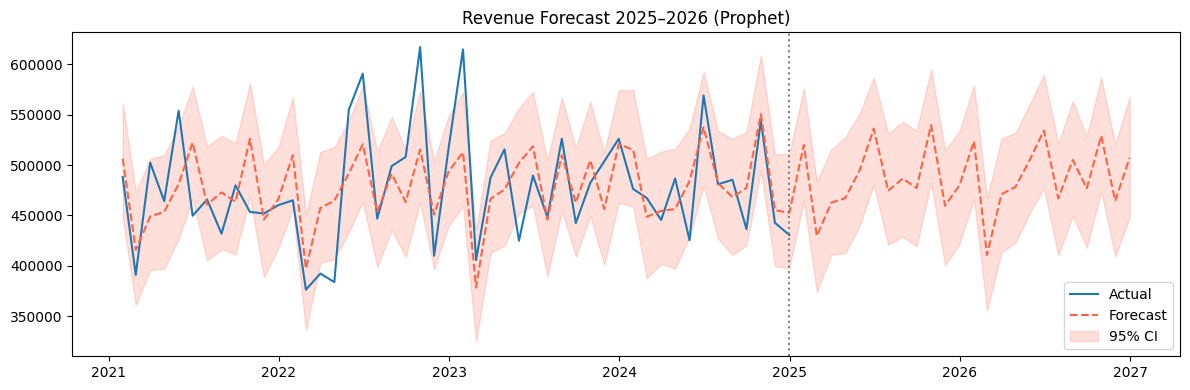

In [50]:
warnings.filterwarnings('ignore')

# Fitting the model
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(monthly)

# Predicting using the model
future   = model.make_future_dataframe(periods=24, freq='ME')
forecast = model.predict(future)

# Plotting predictions
plt.figure(figsize=(12, 4))
plt.plot(monthly['ds'], monthly['y'], label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], linestyle='--', color='tomato', label='Forecast')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], alpha=0.2, color='tomato', label='95% CI')
plt.axvline(x=monthly['ds'].iloc[-1], color='gray', linestyle=':')
plt.title('Revenue Forecast 2025–2026 (Prophet)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#the model predicts the following years while keeping in mind seasonality, which seems to be a better fit for teh data

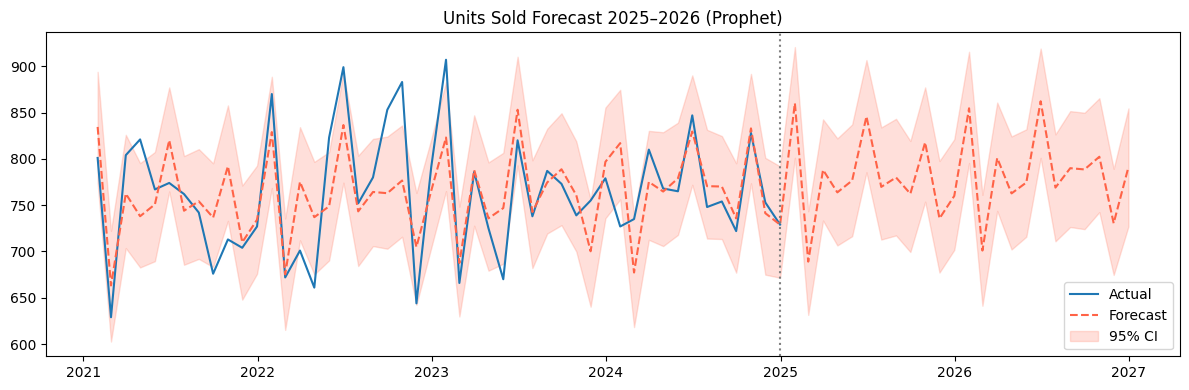

In [51]:
warnings.filterwarnings('ignore')

# Fitting the model
model2 = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model2.fit(monthly2)

# Predicting using the model
future2   = model2.make_future_dataframe(periods=24, freq='ME')
forecast2 = model2.predict(future2)

# Plotting predictions
plt.figure(figsize=(12, 4))
plt.plot(monthly2['ds'], monthly2['y'], label='Actual')
plt.plot(forecast2['ds'], forecast2['yhat'], linestyle='--', color='tomato', label='Forecast')
plt.fill_between(forecast2['ds'], forecast2['yhat_lower'], forecast2['yhat_upper'], alpha=0.2, color='tomato', label='95% CI')
plt.axvline(x=monthly2['ds'].iloc[-1], color='gray', linestyle=':')
plt.title('Units Sold Forecast 2025–2026 (Prophet)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# these are the expected numbers for the following years based on trends of the last years's seasona trends.